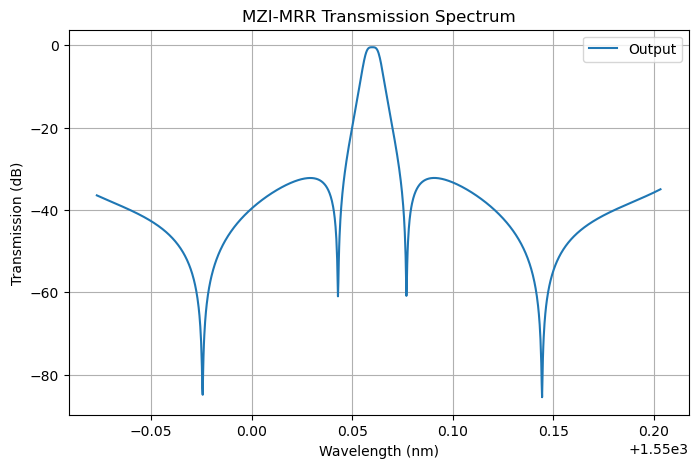

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 参数定义
# ===============================
f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)
c = 3e8

E1 = 0
E2 = 1

Ki = 0.5  # 3dB耦合器功率耦合系数
Ko = 0.5
ai = np.sqrt(1 - Ki)
bi = -1j * np.sqrt(Ki)
ao = np.sqrt(1 - Ko)
bo = -1j * np.sqrt(Ko)

thetai = 0.5 * np.pi  # MZI上臂相移
thetao = 0.5 * np.pi

fait = 0.495 * np.pi  # MZI上臂相移
faib = -0.495 * np.pi  # MZI下臂相移

fai1 = -0.0468 * np.pi
fai2 = -0.6842 * np.pi
fai3 = -0.0518 * np.pi
fai4 = -0.6198 * np.pi

theta1 = -0.622 * np.pi
theta2 = -0.73 * np.pi
theta3 = -0.622 * np.pi
theta4 = -0.73 * np.pi

k = np.cos(theta1 / 2)
t = np.sqrt(1 - k ** 2)

Alfadb = 15  # 功率损耗因子
alfadb = Alfadb / 2  # 场强损耗因子
alfa = alfadb * np.log(10) / 10
neff = 2.2998
ng = 4.3
L1 = 350e-6
L3 = 350e-6
L2 = 3000e-6
L4 = 3000e-6

fsr1 = c / (L1 * ng)  # 微环FSR
fsr2 = c / (L2 * ng)
tao1 = np.exp(-alfa * L1)
tao2 = np.exp(-alfa * L2)
tao3 = np.exp(-alfa * L3)
tao4 = np.exp(-alfa * L4)

# ===============================
# 计算各臂的相位延迟
# ===============================
fai11 = 2 * np.pi * f * L1 * ng / c
fai22 = 2 * np.pi * f * L2 * ng / c
fai33 = 2 * np.pi * f * L3 * ng / c
fai44 = 2 * np.pi * f * L4 * ng / c

# ===============================
# 输入耦合
# ===============================
E3 = np.sqrt(1 - Ki) * E1 - 1j * np.sqrt(Ki) * E2
E4 = -1j * np.sqrt(Ki) * E1 + np.sqrt(1 - Ki) * E2
E5 = E3
E6 = np.exp(1j * thetai) * E4
E7 = np.sqrt(1 - Ki) * E5 - 1j * np.sqrt(Ki) * E6
E8 = -1j * np.sqrt(Ki) * E5 + np.sqrt(1 - Ki) * E6

# ===============================
# 频率扫描
# ===============================
N = len(f)

C1 = np.zeros(N)
C2 = np.zeros(N)

for i in range(N):
    c1 = ((np.exp(1j * theta1) - 1) / 2 - tao1 * np.exp(1j * (fai1 + theta1 + fai11[i]))) / (
            1 - tao1 * (1 - np.exp(1j * theta1)) * np.exp(1j * (fai11[i] + fai1)) / 2)
    c2 = ((np.exp(1j * theta2) - 1) / 2 - tao2 * np.exp(1j * (fai2 + theta2 + fai22[i]))) / (
            1 - tao2 * (1 - np.exp(1j * theta2)) * np.exp(1j * (fai22[i] + fai2)) / 2)
    A1 = np.exp(1j * fait) * c1 * c2

    c3 = ((np.exp(1j * theta3) - 1) / 2 - tao3 * np.exp(1j * (fai3 + theta3 + fai33[i]))) / (
            1 - tao3 * (1 - np.exp(1j * theta3)) * np.exp(1j * (fai33[i] + fai3)) / 2)
    c4 = ((np.exp(1j * theta4) - 1) / 2 - tao4 * np.exp(1j * (fai4 + theta4 + fai44[i]))) / (
            1 - tao4 * (1 - np.exp(1j * theta4)) * np.exp(1j * (fai44[i] + fai4)) / 2)
    A2 = np.exp(1j * faib) * c3 * c4

    E9 = A1 * E7
    E10 = A2 * E8
    E11 = np.sqrt(1 - Ko) * E9 - 1j * np.sqrt(Ko) * E10
    E12 = -1j * np.sqrt(Ko) * E9 + np.sqrt(1 - Ko) * E10
    E13 = E11
    E14 = np.exp(1j * thetao) * E12
    E15 = np.sqrt(1 - Ko) * E13 - 1j * np.sqrt(Ko) * E14
    E16 = -1j * np.sqrt(Ko) * E13 + np.sqrt(1 - Ko) * E14

    C1[i] = np.abs(E15) ** 2
    C2[i] = np.abs(E16) ** 2

CdB1 = 10 * np.log10(C1)
CdB2 = 10 * np.log10(C2)

# ===============================
# 计算波长
# ===============================
lambda_ = c / f

# ===============================
# 绘图
# ===============================
plt.figure(figsize=(8, 5))
plt.plot(lambda_ * 1e9, CdB2, label='Output')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.title('MZI-MRR Transmission Spectrum')
plt.legend()
plt.grid(True)
plt.show()

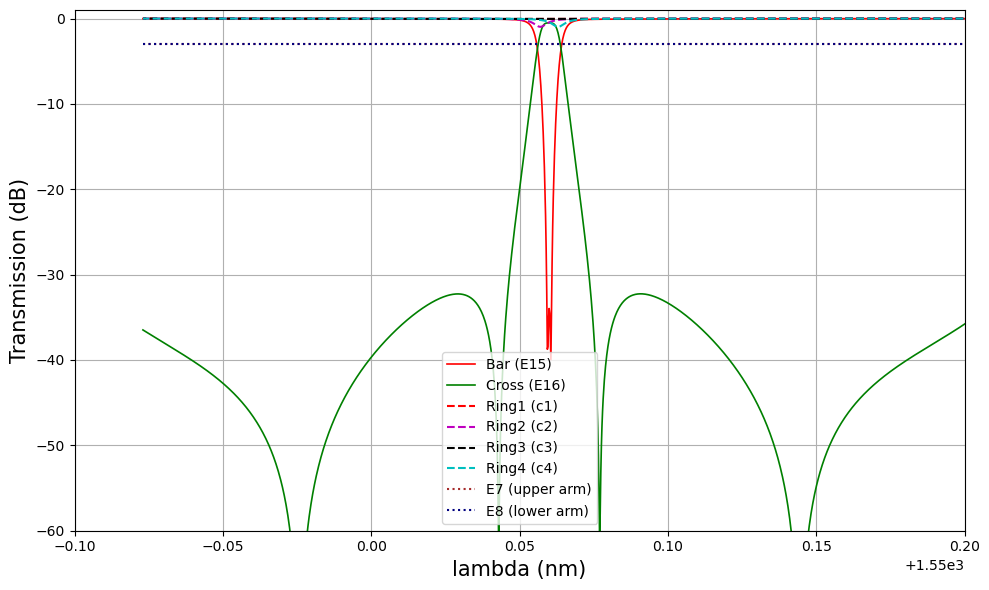

: 

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 参数定义
# ===============================
f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)
c = 3e8

E1 = 0
E2 = 1

Ki = 0.5  # 3dB耦合器功率耦合系数
Ko = 0.5
ai = np.sqrt(1 - Ki)
bi = -1j * np.sqrt(Ki)
ao = np.sqrt(1 - Ko)
bo = -1j * np.sqrt(Ko)

thetai = 0.5 * np.pi  # MZI上臂相移
thetao = 0.5 * np.pi

fait = 0.495 * np.pi  # MZI上臂相移
faib = -0.495 * np.pi  # MZI下臂相移

fai1 = -0.0468 * np.pi
fai2 = -0.6842 * np.pi
fai3 = -0.0518 * np.pi
fai4 = -0.6198 * np.pi

theta1 = -0.622 * np.pi
theta2 = -0.73 * np.pi
theta3 = -0.622 * np.pi
theta4 = -0.73 * np.pi

k = np.cos(theta1 / 2)
t = np.sqrt(1 - k ** 2)

Alfadb = 15  # 功率损耗因子
alfadb = Alfadb / 2  # 场强损耗因子
alfa = alfadb * np.log(10) / 10
neff = 2.2998
ng = 4.3
L1 = 350e-6
L3 = 350e-6
L2 = 3000e-6
L4 = 3000e-6

fsr1 = c / (L1 * ng)  # 微环FSR
fsr2 = c / (L2 * ng)
tao1 = np.exp(-alfa * L1)
tao2 = np.exp(-alfa * L2)
tao3 = np.exp(-alfa * L3)
tao4 = np.exp(-alfa * L4)

# ===============================
# 计算各臂的相位延迟
# ===============================
fai11 = 2 * np.pi * f * L1 * ng / c
fai22 = 2 * np.pi * f * L2 * ng / c
fai33 = 2 * np.pi * f * L3 * ng / c
fai44 = 2 * np.pi * f * L4 * ng / c

# ===============================
# 输入耦合
# ===============================
E3 = np.sqrt(1 - Ki) * E1 - 1j * np.sqrt(Ki) * E2
E4 = -1j * np.sqrt(Ki) * E1 + np.sqrt(1 - Ki) * E2
E5 = E3
E6 = np.exp(1j * thetai) * E4
E7 = np.sqrt(1 - Ki) * E5 - 1j * np.sqrt(Ki) * E6
E8 = -1j * np.sqrt(Ki) * E5 + np.sqrt(1 - Ki) * E6

# ===============================
# 频率扫描并得到 CdB1, CdB2
# ===============================
N = len(f)
C1 = np.zeros(N)
C2 = np.zeros(N)

for i in range(N):
    c1 = ((np.exp(1j * theta1) - 1) / 2 - tao1 * np.exp(1j * (fai1 + theta1 + fai11[i]))) / (
            1 - tao1 * (1 - np.exp(1j * theta1)) * np.exp(1j * (fai11[i] + fai1)) / 2)
    c2 = ((np.exp(1j * theta2) - 1) / 2 - tao2 * np.exp(1j * (fai2 + theta2 + fai22[i]))) / (
            1 - tao2 * (1 - np.exp(1j * theta2)) * np.exp(1j * (fai22[i] + fai2)) / 2)
    A1 = np.exp(1j * fait) * c1 * c2

    c3 = ((np.exp(1j * theta3) - 1) / 2 - tao3 * np.exp(1j * (fai3 + theta3 + fai33[i]))) / (
            1 - tao3 * (1 - np.exp(1j * theta3)) * np.exp(1j * (fai33[i] + fai3)) / 2)
    c4 = ((np.exp(1j * theta4) - 1) / 2 - tao4 * np.exp(1j * (fai4 + theta4 + fai44[i]))) / (
            1 - tao4 * (1 - np.exp(1j * theta4)) * np.exp(1j * (fai44[i] + fai4)) / 2)
    A2 = np.exp(1j * faib) * c3 * c4

    E9 = A1 * E7
    E10 = A2 * E8
    E11 = np.sqrt(1 - Ko) * E9 - 1j * np.sqrt(Ko) * E10
    E12 = -1j * np.sqrt(Ko) * E9 + np.sqrt(1 - Ko) * E10
    E13 = E11
    E14 = np.exp(1j * thetao) * E12
    E15 = np.sqrt(1 - Ko) * E13 - 1j * np.sqrt(Ko) * E14
    E16 = -1j * np.sqrt(Ko) * E13 + np.sqrt(1 - Ko) * E14

    C1[i] = np.abs(E15) ** 2
    C2[i] = np.abs(E16) ** 2

CdB1 = 10 * np.log10(C1)
CdB2 = 10 * np.log10(C2)

# ===============================
# 计算波长
# ===============================
lambda_ = c / f

# ===============================
# 绘图部分
# ===============================

# 重新向量化计算 c1..c4
c1_arr = ((np.exp(1j * theta1) - 1) / 2 - tao1 * np.exp(1j * (fai1 + theta1 + fai11))) / \
         (1 - tao1 * (1 - np.exp(1j * theta1)) * np.exp(1j * (fai11 + fai1)) / 2)

c2_arr = ((np.exp(1j * theta2) - 1) / 2 - tao2 * np.exp(1j * (fai2 + theta2 + fai22))) / \
         (1 - tao2 * (1 - np.exp(1j * theta2)) * np.exp(1j * (fai22 + fai2)) / 2)

c3_arr = ((np.exp(1j * theta3) - 1) / 2 - tao3 * np.exp(1j * (fai3 + theta3 + fai33))) / \
         (1 - tao3 * (1 - np.exp(1j * theta3)) * np.exp(1j * (fai33 + fai3)) / 2)

c4_arr = ((np.exp(1j * theta4) - 1) / 2 - tao4 * np.exp(1j * (fai4 + theta4 + fai44))) / \
         (1 - tao4 * (1 - np.exp(1j * theta4)) * np.exp(1j * (fai44 + fai4)) / 2)

# 转成功率 (dB)
c1dB = 10 * np.log10(np.abs(c1_arr) ** 2)
c2dB = 10 * np.log10(np.abs(c2_arr) ** 2)
c3dB = 10 * np.log10(np.abs(c3_arr) ** 2)
c4dB = 10 * np.log10(np.abs(c4_arr) ** 2)

# E7, E8 的功率
P7 = np.abs(E7) ** 2
P8 = np.abs(E8) ** 2
P7dB = 10 * np.log10(P7)
P8dB = 10 * np.log10(P8)

# 绘图
plt.figure(figsize=(10, 6))
# 主输出（Cross / Bar）
plt.plot(lambda_ * 1e9, CdB1, color='r', linewidth=1.2, label='Bar (E15)')   # Bar
plt.plot(lambda_ * 1e9, CdB2, color='g', linewidth=1.2, label='Cross (E16)') # Cross

# Ring 曲线
plt.plot(lambda_ * 1e9, c1dB, '--r', label='Ring1 (c1)')
plt.plot(lambda_ * 1e9, c2dB, '--m', label='Ring2 (c2)')
plt.plot(lambda_ * 1e9, c3dB, '--k', label='Ring3 (c3)')
plt.plot(lambda_ * 1e9, c4dB, '--c', label='Ring4 (c4)')

# E7, E8 作为水平线
plt.hlines(P7dB, xmin=lambda_.min() * 1e9, xmax=lambda_.max() * 1e9, colors='brown', linestyles=':', label='E7 (upper arm)')
plt.hlines(P8dB, xmin=lambda_.min() * 1e9, xmax=lambda_.max() * 1e9, colors='navy', linestyles=':', label='E8 (lower arm)')

# 图形美化
ax = plt.gca()
ax.tick_params(labelsize=10)
plt.xlabel('lambda (nm)', fontsize=15)
plt.ylabel('Transmission (dB)', fontsize=15)
plt.xlim(1549.9, 1550.2)
plt.ylim(-60, 1)
plt.legend(fontsize=10, loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# =====================================
# 主计算函数
# =====================================
def MZI_MRR(fait_val, faib_val, fai1_val, fai2_val, fai3_val, fai4_val, 
             theta1_val, theta2_val, theta3_val, theta4_val):

    # ===== 固定参数 =====
    f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)
    c = 3e8
    E1, E2 = 0, 1
    Ki, Ko = 0.5, 0.5
    thetai = 0.5 * np.pi
    thetao = 0.5 * np.pi

    Alfadb = 15
    alfadb = Alfadb / 2
    alfa = alfadb * np.log(10) / 10
    ng = 4.3
    L1, L2, L3, L4 = 350e-6, 3000e-6, 350e-6, 3000e-6

    tao1, tao2, tao3, tao4 = [np.exp(-alfa * L) for L in [L1, L2, L3, L4]]

    # ===== 相位延迟 =====
    fai11 = 2 * np.pi * f * L1 * ng / c
    fai22 = 2 * np.pi * f * L2 * ng / c
    fai33 = 2 * np.pi * f * L3 * ng / c
    fai44 = 2 * np.pi * f * L4 * ng / c

    # ===== 输入耦合 =====
    E3 = np.sqrt(1 - Ki) * E1 - 1j * np.sqrt(Ki) * E2
    E4 = -1j * np.sqrt(Ki) * E1 + np.sqrt(1 - Ki) * E2
    E5, E6 = E3, np.exp(1j * thetai) * E4
    E7 = np.sqrt(1 - Ki) * E5 - 1j * np.sqrt(Ki) * E6
    E8 = -1j * np.sqrt(Ki) * E5 + np.sqrt(1 - Ki) * E6

    # ===== 频率扫描 =====
    N = len(f)
    C2 = np.zeros(N)

    for i in range(N):
        c1 = ((np.exp(1j * theta1_val) - 1) / 2 - tao1 * np.exp(1j * (fai1_val + theta1_val + fai11[i]))) / (
                1 - tao1 * (1 - np.exp(1j * theta1_val)) * np.exp(1j * (fai11[i] + fai1_val)) / 2)
        c2 = ((np.exp(1j * theta2_val) - 1) / 2 - tao2 * np.exp(1j * (fai2_val + theta2_val + fai22[i]))) / (
                1 - tao2 * (1 - np.exp(1j * theta2_val)) * np.exp(1j * (fai22[i] + fai2_val)) / 2)
        A1 = np.exp(1j * fait_val) * c1 * c2

        c3 = ((np.exp(1j * theta3_val) - 1) / 2 - tao3 * np.exp(1j * (fai3_val + theta3_val + fai33[i]))) / (
                1 - tao3 * (1 - np.exp(1j * theta3_val)) * np.exp(1j * (fai33[i] + fai3_val)) / 2)
        c4 = ((np.exp(1j * theta4_val) - 1) / 2 - tao4 * np.exp(1j * (fai4_val + theta4_val + fai44[i]))) / (
                1 - tao4 * (1 - np.exp(1j * theta4_val)) * np.exp(1j * (fai44[i] + fai4_val)) / 2)
        A2 = np.exp(1j * faib_val) * c3 * c4

        E9, E10 = A1 * E7, A2 * E8
        E11 = np.sqrt(1 - Ko) * E9 - 1j * np.sqrt(Ko) * E10
        E12 = -1j * np.sqrt(Ko) * E9 + np.sqrt(1 - Ko) * E10
        E13 = E11
        E14 = np.exp(1j * thetao) * E12
        E15 = np.sqrt(1 - Ko) * E13 - 1j * np.sqrt(Ko) * E14
        E16 = -1j * np.sqrt(Ko) * E13 + np.sqrt(1 - Ko) * E14

        C2[i] = np.abs(E16) ** 2

    CdB2 = 10 * np.log10(C2)
    lambda_ = c / f

    # ===== 绘图 =====
    plt.figure(figsize=(7, 4))
    plt.plot(lambda_ * 1e9, CdB2, color='royalblue')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmission (dB)')
    plt.title('MZI-MRR Spectrum (Interactive)')
    plt.grid(True)
    plt.show()


# =====================================
# 交互界面
# =====================================
interact(
    MZI_MRR,
    fait_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=0.495*np.pi, description='fait'),
    faib_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.495*np.pi, description='faib'),
    fai1_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.0468*np.pi, description='fai1'),
    fai2_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.6842*np.pi, description='fai2'),
    fai3_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.0518*np.pi, description='fai3'),
    fai4_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.6198*np.pi, description='fai4'),
    theta1_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.622*np.pi, description='theta1'),
    theta2_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.73*np.pi, description='theta2'),
    theta3_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.622*np.pi, description='theta3'),
    theta4_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.73*np.pi, description='theta4')
);

interactive(children=(FloatSlider(value=1.5550883635269477, description='fait', max=3.141592653589793, min=-3.…

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 参数定义
# ===============================
def MZI_MRR(fait_val, faib_val, fai1_val, fai2_val, fai3_val, fai4_val, 
             theta1_val, theta2_val, theta3_val, theta4_val):
    
        f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)
        c = 3e8

        E1 = 0
        E2 = 1

        Ki = 0.5  # 3dB耦合器功率耦合系数
        Ko = 0.5
        ai = np.sqrt(1 - Ki)
        bi = -1j * np.sqrt(Ki)
        ao = np.sqrt(1 - Ko)
        bo = -1j * np.sqrt(Ko)

        thetai = 0.5 * np.pi  # MZI上臂相移
        thetao = 0.5 * np.pi

        fait = 0.495 * np.pi  # MZI上臂相移
        faib = -0.495 * np.pi  # MZI下臂相移

        fai1 = -0.0468 * np.pi
        fai2 = -0.6842 * np.pi
        fai3 = -0.0518 * np.pi
        fai4 = -0.6198 * np.pi

        theta1 = -0.622 * np.pi
        theta2 = -0.73 * np.pi
        theta3 = -0.622 * np.pi
        theta4 = -0.73 * np.pi

        k = np.cos(theta1 / 2)
        t = np.sqrt(1 - k ** 2)

        Alfadb = 15  # 功率损耗因子
        alfadb = Alfadb / 2  # 场强损耗因子
        alfa = alfadb * np.log(10) / 10
        neff = 2.2998
        ng = 4.3
        L1 = 350e-6
        L3 = 350e-6
        L2 = 3000e-6
        L4 = 3000e-6

        fsr1 = c / (L1 * ng)  # 微环FSR
        fsr2 = c / (L2 * ng)
        tao1 = np.exp(-alfa * L1)
        tao2 = np.exp(-alfa * L2)
        tao3 = np.exp(-alfa * L3)
        tao4 = np.exp(-alfa * L4)

        # ===============================
        # 计算各臂的相位延迟
        # ===============================
        fai11 = 2 * np.pi * f * L1 * ng / c
        fai22 = 2 * np.pi * f * L2 * ng / c
        fai33 = 2 * np.pi * f * L3 * ng / c
        fai44 = 2 * np.pi * f * L4 * ng / c

        # ===============================
        # 输入耦合
        # ===============================
        E3 = np.sqrt(1 - Ki) * E1 - 1j * np.sqrt(Ki) * E2
        E4 = -1j * np.sqrt(Ki) * E1 + np.sqrt(1 - Ki) * E2
        E5 = E3
        E6 = np.exp(1j * thetai) * E4
        E7 = np.sqrt(1 - Ki) * E5 - 1j * np.sqrt(Ki) * E6
        E8 = -1j * np.sqrt(Ki) * E5 + np.sqrt(1 - Ki) * E6

        # ===============================
        # 频率扫描并得到 CdB1, CdB2
        # ===============================
        N = len(f)
        C1 = np.zeros(N)
        C2 = np.zeros(N)

        for i in range(N):
                c1 = ((np.exp(1j * theta1) - 1) / 2 - tao1 * np.exp(1j * (fai1 + theta1 + fai11[i]))) / (
                        1 - tao1 * (1 - np.exp(1j * theta1)) * np.exp(1j * (fai11[i] + fai1)) / 2)
                c2 = ((np.exp(1j * theta2) - 1) / 2 - tao2 * np.exp(1j * (fai2 + theta2 + fai22[i]))) / (
                        1 - tao2 * (1 - np.exp(1j * theta2)) * np.exp(1j * (fai22[i] + fai2)) / 2)
                A1 = np.exp(1j * fait) * c1 * c2

                c3 = ((np.exp(1j * theta3) - 1) / 2 - tao3 * np.exp(1j * (fai3 + theta3 + fai33[i]))) / (
                        1 - tao3 * (1 - np.exp(1j * theta3)) * np.exp(1j * (fai33[i] + fai3)) / 2)
                c4 = ((np.exp(1j * theta4) - 1) / 2 - tao4 * np.exp(1j * (fai4 + theta4 + fai44[i]))) / (
                        1 - tao4 * (1 - np.exp(1j * theta4)) * np.exp(1j * (fai44[i] + fai4)) / 2)
                A2 = np.exp(1j * faib) * c3 * c4

        E9 = A1 * E7
        E10 = A2 * E8
        E11 = np.sqrt(1 - Ko) * E9 - 1j * np.sqrt(Ko) * E10
        E12 = -1j * np.sqrt(Ko) * E9 + np.sqrt(1 - Ko) * E10
        E13 = E11
        E14 = np.exp(1j * thetao) * E12
        E15 = np.sqrt(1 - Ko) * E13 - 1j * np.sqrt(Ko) * E14
        E16 = -1j * np.sqrt(Ko) * E13 + np.sqrt(1 - Ko) * E14

        C1[i] = np.abs(E15) ** 2
        C2[i] = np.abs(E16) ** 2

        CdB1 = 10 * np.log10(C1)
        CdB2 = 10 * np.log10(C2)

        # ===============================
        # 计算波长
        # ===============================
        lambda_ = c / f

        # ===============================
        # 绘图部分
        # ===============================

        # 重新向量化计算 c1..c4
        c1_arr = ((np.exp(1j * theta1) - 1) / 2 - tao1 * np.exp(1j * (fai1 + theta1 + fai11))) / \
                (1 - tao1 * (1 - np.exp(1j * theta1)) * np.exp(1j * (fai11 + fai1)) / 2)

        c2_arr = ((np.exp(1j * theta2) - 1) / 2 - tao2 * np.exp(1j * (fai2 + theta2 + fai22))) / \
                (1 - tao2 * (1 - np.exp(1j * theta2)) * np.exp(1j * (fai22 + fai2)) / 2)

        c3_arr = ((np.exp(1j * theta3) - 1) / 2 - tao3 * np.exp(1j * (fai3 + theta3 + fai33))) / \
                (1 - tao3 * (1 - np.exp(1j * theta3)) * np.exp(1j * (fai33 + fai3)) / 2)

        c4_arr = ((np.exp(1j * theta4) - 1) / 2 - tao4 * np.exp(1j * (fai4 + theta4 + fai44))) / \
                (1 - tao4 * (1 - np.exp(1j * theta4)) * np.exp(1j * (fai44 + fai4)) / 2)

        # 转成功率 (dB)
        c1dB = 10 * np.log10(np.abs(c1_arr) ** 2)
        c2dB = 10 * np.log10(np.abs(c2_arr) ** 2)
        c3dB = 10 * np.log10(np.abs(c3_arr) ** 2)
        c4dB = 10 * np.log10(np.abs(c4_arr) ** 2)

        # E7, E8 的功率
        P7 = np.abs(E7) ** 2
        P8 = np.abs(E8) ** 2
        P7dB = 10 * np.log10(P7)
        P8dB = 10 * np.log10(P8)

        # 绘图
        plt.figure(figsize=(10, 6))
        # 主输出（Cross / Bar）
        plt.plot(lambda_ * 1e9, CdB1, color='r', linewidth=1.2, label='Bar (E15)')   # Bar
        plt.plot(lambda_ * 1e9, CdB2, color='g', linewidth=1.2, label='Cross (E16)') # Cross

        # Ring 曲线
        plt.plot(lambda_ * 1e9, c1dB, '--r', label='Ring1 (c1)')
        plt.plot(lambda_ * 1e9, c2dB, '--m', label='Ring2 (c2)')
        plt.plot(lambda_ * 1e9, c3dB, '--k', label='Ring3 (c3)')
        plt.plot(lambda_ * 1e9, c4dB, '--c', label='Ring4 (c4)')

        # E7, E8 作为水平线
        plt.hlines(P7dB, xmin=lambda_.min() * 1e9, xmax=lambda_.max() * 1e9, colors='brown', linestyles=':', label='E7 (upper arm)')
        plt.hlines(P8dB, xmin=lambda_.min() * 1e9, xmax=lambda_.max() * 1e9, colors='navy', linestyles=':', label='E8 (lower arm)')

        # 图形美化
        ax = plt.gca()
        ax.tick_params(labelsize=10)
        plt.xlabel('lambda (nm)', fontsize=15)
        plt.ylabel('Transmission (dB)', fontsize=15)
        plt.xlim(1549.9, 1550.2)
        plt.ylim(-60, 1)
        plt.legend(fontsize=10, loc='best')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# =====================================
# 交互界面
# =====================================
interact(
    MZI_MRR,
    fait_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=0.495*np.pi, description='fait'),
    faib_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.495*np.pi, description='faib'),
    fai1_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.0468*np.pi, description='fai1'),
    fai2_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.6842*np.pi, description='fai2'),
    fai3_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.0518*np.pi, description='fai3'),
    fai4_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.6198*np.pi, description='fai4'),
    theta1_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.622*np.pi, description='theta1'),
    theta2_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.73*np.pi, description='theta2'),
    theta3_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.622*np.pi, description='theta3'),
    theta4_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.73*np.pi, description='theta4')
);

NameError: name 'interact' is not defined

: 

: 

: 

Generation 1/40, best loss=11.727295
Generation 2/40, best loss=11.727295
Generation 3/40, best loss=9.416956
Generation 4/40, best loss=9.416956
Generation 5/40, best loss=8.530699
Generation 6/40, best loss=3.201976
Generation 7/40, best loss=3.201976
Generation 8/40, best loss=2.319483
Generation 9/40, best loss=1.202913
Generation 10/40, best loss=1.202913
Generation 11/40, best loss=0.968145
Generation 12/40, best loss=0.668767
Generation 13/40, best loss=0.560454
Generation 14/40, best loss=0.464004
Generation 15/40, best loss=0.398293
Generation 16/40, best loss=0.398293
Generation 17/40, best loss=0.333092
Generation 18/40, best loss=0.333092
Generation 19/40, best loss=0.302097
Generation 20/40, best loss=0.116531
Generation 21/40, best loss=0.051671
Generation 22/40, best loss=0.051671
Generation 23/40, best loss=0.051671
Generation 24/40, best loss=0.043223
Generation 25/40, best loss=0.028924
Generation 26/40, best loss=0.028924
Generation 27/40, best loss=0.026622
Generati

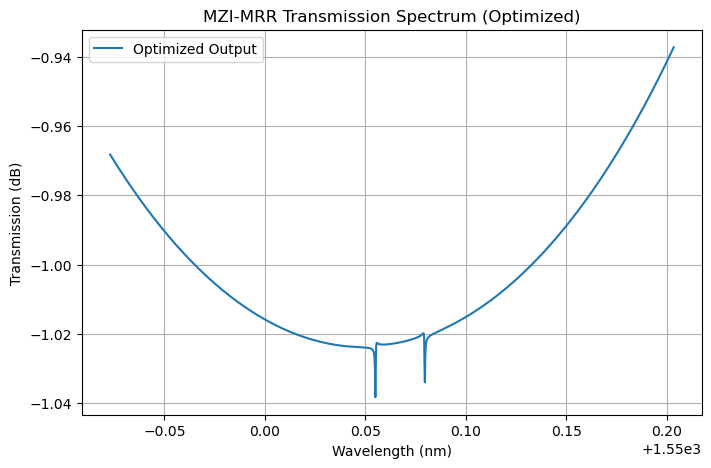

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct

# ==========================================================
# =============== 原始代码：系统参数（保持不变） ===============
# ==========================================================

f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)  # 频率扫描
c = 3e8

E1 = 0
E2 = 1

Ki = 0.5
Ko = 0.5
ai = np.sqrt(1 - Ki)
bi = -1j * np.sqrt(Ki)
ao = np.sqrt(1 - Ko)
bo = -1j * np.sqrt(Ko)

thetai = 0.5 * np.pi
thetao = 0.5 * np.pi

# 这些参数将被 GA 优化：fait, faib, fai1~4, theta1~4
# 但你规定了：theta1=theta3, theta2=theta4, fait = -faib

# 初始值不会影响 GA，但需要定义
fait0 = 0.495*np.pi
faib0 = -0.495*np.pi
fai_initial = [-0.0468*np.pi, -0.6842*np.pi, -0.0518*np.pi, -0.6198*np.pi]
theta_initial = [-0.622*np.pi, -0.73*np.pi]

# 固定参数（保持不变）
k = np.cos(theta_initial[0]/2)
t = np.sqrt(1 - k**2)

Alfadb = 15
alfadb = Alfadb / 2
alfa = alfadb * np.log(10) / 10
neff = 2.2998
ng = 4.3
L1 = 350e-6
L3 = 350e-6
L2 = 3000e-6
L4 = 3000e-6

tao1 = np.exp(-alfa * L1)
tao2 = np.exp(-alfa * L2)
tao3 = np.exp(-alfa * L3)
tao4 = np.exp(-alfa * L4)

# 相位延迟（保持不变）
fai11 = 2*np.pi*f*L1*ng/c
fai22 = 2*np.pi*f*L2*ng/c
fai33 = 2*np.pi*f*L3*ng/c
fai44 = 2*np.pi*f*L4*ng/c

N = len(f)
lambda_ = c/f


# ==========================================================
# =============== 计算光谱函数（保持不变） ====================
# ==========================================================

def simulate_spectrum(fait, fai1, fai2, fai3, fai4, theta1, theta2):
    """根据给定参数计算输出光谱"""
    faib = -fait    # 你的约束
    theta3 = theta1
    theta4 = theta2

    C1 = np.zeros(N)
    C2 = np.zeros(N)

    for i in range(N):
        c1 = ((np.exp(1j*theta1)-1)/2 - tao1*np.exp(1j*(fai1+theta1+fai11[i]))) / \
             (1 - tao1*(1-np.exp(1j*theta1))*np.exp(1j*(fai11[i]+fai1))/2)
        c2 = ((np.exp(1j*theta2)-1)/2 - tao2*np.exp(1j*(fai2+theta2+fai22[i]))) / \
             (1 - tao2*(1-np.exp(1j*theta2))*np.exp(1j*(fai22[i]+fai2))/2)
        A1 = np.exp(1j*fait)*c1*c2

        c3 = ((np.exp(1j*theta3)-1)/2 - tao3*np.exp(1j*(fai3+theta3+fai33[i]))) / \
             (1 - tao3*(1-np.exp(1j*theta3))*np.exp(1j*(fai33[i]+fai3))/2)
        c4 = ((np.exp(1j*theta4)-1)/2 - tao4*np.exp(1j*(fai4+theta4+fai44[i]))) / \
             (1 - tao4*(1-np.exp(1j*theta4))*np.exp(1j*(fai44[i]+fai4))/2)
        A2 = np.exp(1j*faib)*c3*c4

        E3 = np.sqrt(1-Ki)*E1 - 1j*np.sqrt(Ki)*E2
        E4 = -1j*np.sqrt(Ki)*E1 + np.sqrt(1-Ki)*E2
        E5 = E3
        E6 = np.exp(1j*thetai)*E4
        E7 = np.sqrt(1-Ki)*E5 - 1j*np.sqrt(Ki)*E6
        E8 = -1j*np.sqrt(Ki)*E5 + np.sqrt(1-Ki)*E6

        E9  = A1 * E7
        E10 = A2 * E8
        E11 = np.sqrt(1-Ko)*E9 - 1j*np.sqrt(Ko)*E10
        E12 = -1j*np.sqrt(Ko)*E9 + np.sqrt(1-Ko)*E10
        E13 = E11
        E14 = np.exp(1j*thetao)*E12
        E15 = np.sqrt(1-Ko)*E13 - 1j*np.sqrt(Ko)*E14
        E16 = -1j*np.sqrt(Ko)*E13 + np.sqrt(1-Ko)*E14

        C2[i] = np.abs(E16)**2

    return 10*np.log10(C2)


# ==========================================================
# ===================== DCT Loss 函数 =======================
# ==========================================================

K = 40  # 取前 K 维频域特征，你可根据实际情况改
def dct_loss(y, target):
    Y = dct(y, type=2, norm='ortho')
    T = dct(target, type=2, norm='ortho')
    return np.mean((Y[:K] - T[:K])**2)


# ==========================================================
# ===================== 构造“目标波形” ======================
# ==========================================================

# 自动寻找通带中心
idx_peak = np.argmax(simulate_spectrum(fait0,
                                       fai_initial[0], fai_initial[1],
                                       fai_initial[2], fai_initial[3],
                                       theta_initial[0], theta_initial[1]))

lambda_center = lambda_[idx_peak]
bandwidth = 0.03  # nm

target = np.full(N, -40)
target[np.abs(lambda_ - lambda_center) < bandwidth] = -1


# ==========================================================
# ==================== 遗传算法参数 =========================
# ==========================================================

pop_size = 30
generations = 40
mutation_rate = 0.2

def random_param():
    return {
        "fait": np.random.uniform(-np.pi, np.pi),
        "fai1": np.random.uniform(-np.pi, np.pi),
        "fai2": np.random.uniform(-np.pi, np.pi),
        "fai3": np.random.uniform(-np.pi, np.pi),
        "fai4": np.random.uniform(-np.pi, np.pi),
        "theta1": np.random.uniform(-np.pi, np.pi),
        "theta2": np.random.uniform(-np.pi, np.pi),
    }


def evaluate(p):
    y = simulate_spectrum(
        p["fait"],
        p["fai1"], p["fai2"], p["fai3"], p["fai4"],
        p["theta1"], p["theta2"]
    )
    return dct_loss(y, target)


def crossover(a, b):
    child = {}
    for k in a:
        child[k] = a[k] if np.random.rand()<0.5 else b[k]
    return child

def mutate(p):
    for k in p:
        if np.random.rand() < mutation_rate:
            p[k] += np.random.normal(scale=0.1)
    return p


# ==========================================================
# ======================== GA 主循环 ========================
# ==========================================================

population = [random_param() for _ in range(pop_size)]

for gen in range(generations):
    scores = np.array([evaluate(p) for p in population])
    elite_idx = scores.argsort()[:pop_size//3]
    elites = [population[i] for i in elite_idx]

    new_pop = elites.copy()
    while len(new_pop) < pop_size:
        p1, p2 = np.random.choice(elites, 2)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)

    population = new_pop
    print(f"Generation {gen+1}/{generations}, best loss={scores.min():.6f}")

# 最优个体
scores = np.array([evaluate(p) for p in population])
best = population[scores.argmin()]

print("\n================ 最优参数 ================")
for k,v in best.items():
    print(f"{k}: {v}")
print("==========================================\n")


# ==========================================================
# ==================== 最终光谱绘图 ==========================
# ==========================================================

CdB2 = simulate_spectrum(
    best["fait"],
    best["fai1"], best["fai2"], best["fai3"], best["fai4"],
    best["theta1"], best["theta2"]
)

plt.figure(figsize=(8, 5))
plt.plot(lambda_*1e9, CdB2, label='Optimized Output')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.title('MZI-MRR Transmission Spectrum (Optimized)')
plt.legend()
plt.grid(True)
plt.show()

Auto-selected passband center at 1550.0600 nm, passband points: 499
Gen   0: best loss = 5.388332e+02
Gen  10: best loss = 1.215607e+02
Gen  20: best loss = 9.148796e+01
Gen  30: best loss = 8.628633e+01
Gen  40: best loss = 7.462617e+01
Gen  50: best loss = 6.520545e+01
Gen  60: best loss = 6.359349e+01
Gen  70: best loss = 6.027424e+01
Gen  80: best loss = 5.846146e+01
Gen  90: best loss = 5.464143e+01
Gen 100: best loss = 5.444888e+01
Gen 110: best loss = 5.314849e+01
Gen 120: best loss = 5.285931e+01
Gen 130: best loss = 5.220097e+01
Gen 140: best loss = 5.063706e+01
Gen 150: best loss = 5.037581e+01
Gen 160: best loss = 4.861734e+01
Gen 170: best loss = 4.849140e+01
Gen 180: best loss = 4.835797e+01
Gen 190: best loss = 4.755799e+01

Final best loss: 47.40410860404398
Best parameters (order): ['fait', 'fai1', 'fai2', 'fai3', 'fai4', 'theta1', 'theta2']
[-2.971375  0.074411 -2.791686  1.213266  1.895665  2.739665  0.783661]


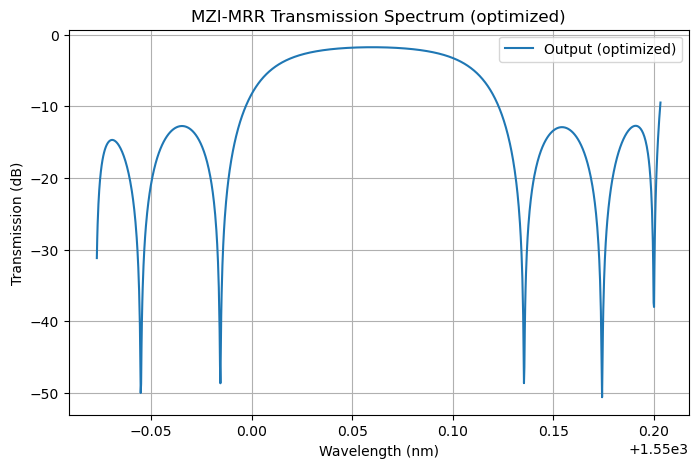

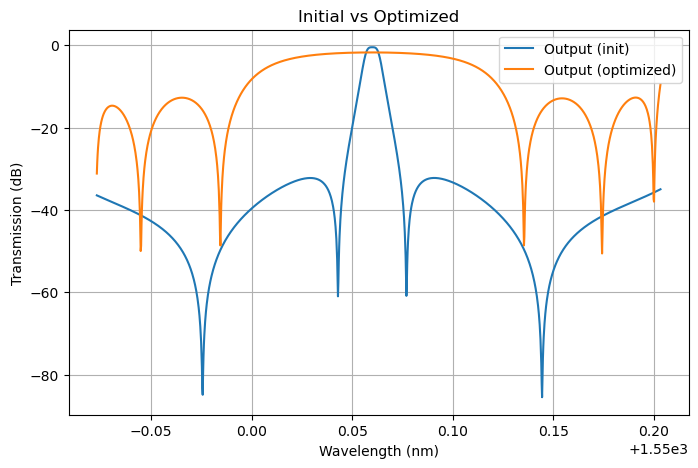

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct
import random
import math

f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)
c = 3e8

E1 = 0
E2 = 1

Ki = 0.5  # 3dB耦合器功率耦合系数
Ko = 0.5
ai = np.sqrt(1 - Ki)
bi = -1j * np.sqrt(Ki)
ao = np.sqrt(1 - Ko)
bo = -1j * np.sqrt(Ko)

# 初始值（这些将被遗传算法改写，但我先保留原变量位置）
thetai = 0.5 * np.pi  # MZI上臂相移
thetao = 0.5 * np.pi

# 为了保持原代码布局，我们声明这些变量但会在 fitness 中覆盖
fait = 0.495 * np.pi  # MZI上臂相移
faib = -0.495 * np.pi  # MZI下臂相移

fai1 = -0.0468 * np.pi
fai2 = -0.6842 * np.pi
fai3 = -0.0518 * np.pi
fai4 = -0.6198 * np.pi

theta1 = -0.622 * np.pi
theta2 = -0.73 * np.pi
theta3 = -0.622 * np.pi
theta4 = -0.73 * np.pi

k = np.cos(theta1 / 2)
t = np.sqrt(1 - k ** 2)

Alfadb = 15  # 功率损耗因子
alfadb = Alfadb / 2  # 场强损耗因子
alfa = alfadb * np.log(10) / 10
neff = 2.2998
ng = 4.3
L1 = 350e-6
L3 = 350e-6
L2 = 3000e-6
L4 = 3000e-6

fsr1 = c / (L1 * ng)  # 微环FSR
fsr2 = c / (L2 * ng)
tao1 = np.exp(-alfa * L1)
tao2 = np.exp(-alfa * L2)
tao3 = np.exp(-alfa * L3)
tao4 = np.exp(-alfa * L4)

# 计算各臂的相位延迟
fai11 = 2 * np.pi * f * L1 * ng / c
fai22 = 2 * np.pi * f * L2 * ng / c
fai33 = 2 * np.pi * f * L3 * ng / c
fai44 = 2 * np.pi * f * L4 * ng / c

# 输入耦合（同原代码）
E3 = np.sqrt(1 - Ki) * E1 - 1j * np.sqrt(Ki) * E2
E4 = -1j * np.sqrt(Ki) * E1 + np.sqrt(1 - Ki) * E2
E5 = E3
E6 = np.exp(1j * thetai) * E4
E7 = np.sqrt(1 - Ki) * E5 - 1j * np.sqrt(Ki) * E6
E8 = -1j * np.sqrt(Ki) * E5 + np.sqrt(1 - Ki) * E6

# 下面实现评估函数：给定要优化的参数，计算 C1, C2

N = len(f)

# Helper: run spectrum with provided parameter set
def compute_spectrum(params):
    # params: [fait, fai1,fai2,fai3,fai4, theta1, theta2]
    # Constraint: theta3 = theta1, theta4 = theta2, faib = -fait
    fait_loc, fai1_loc, fai2_loc, fai3_loc, fai4_loc, theta1_loc, theta2_loc = params
    faib_loc = -fait_loc
    theta3_loc = theta1_loc
    theta4_loc = theta2_loc

    # keep previous global constants (tao, fai11...) unchanged
    C1 = np.zeros(N)
    C2 = np.zeros(N)

    for i in range(N):
        c1 = ((np.exp(1j * theta1_loc) - 1) / 2 - tao1 * np.exp(1j * (fai1_loc + theta1_loc + fai11[i]))) / (
                1 - tao1 * (1 - np.exp(1j * theta1_loc)) * np.exp(1j * (fai11[i] + fai1_loc)) / 2)
        c2 = ((np.exp(1j * theta2_loc) - 1) / 2 - tao2 * np.exp(1j * (fai2_loc + theta2_loc + fai22[i]))) / (
                1 - tao2 * (1 - np.exp(1j * theta2_loc)) * np.exp(1j * (fai22[i] + fai2_loc)) / 2)
        A1 = np.exp(1j * fait_loc) * c1 * c2

        c3 = ((np.exp(1j * theta3_loc) - 1) / 2 - tao3 * np.exp(1j * (fai3_loc + theta3_loc + fai33[i]))) / (
                1 - tao3 * (1 - np.exp(1j * theta3_loc)) * np.exp(1j * (fai33[i] + fai3_loc)) / 2)
        c4 = ((np.exp(1j * theta4_loc) - 1) / 2 - tao4 * np.exp(1j * (fai4_loc + theta4_loc + fai44[i]))) / (
                1 - tao4 * (1 - np.exp(1j * theta4_loc)) * np.exp(1j * (fai44[i] + fai4_loc)) / 2)
        A2 = np.exp(1j * faib_loc) * c3 * c4

        E9 = A1 * E7
        E10 = A2 * E8
        E11 = np.sqrt(1 - Ko) * E9 - 1j * np.sqrt(Ko) * E10
        E12 = -1j * np.sqrt(Ko) * E9 + np.sqrt(1 - Ko) * E10
        E13 = E11
        E14 = np.exp(1j * thetao) * E12
        E15 = np.sqrt(1 - Ko) * E13 - 1j * np.sqrt(Ko) * E14
        E16 = -1j * np.sqrt(Ko) * E13 + np.sqrt(1 - Ko) * E14

        C1[i] = np.abs(E15) ** 2
        C2[i] = np.abs(E16) ** 2

    CdB1 = 10 * np.log10(C1 + 1e-30)
    CdB2 = 10 * np.log10(C2 + 1e-30)

    lambda_ = c / f
    return C1, C2, CdB1, CdB2, lambda_

# 损失函数和若干子罚项

def dct_k_loss(x_lin, target_lin, K):
    X = dct(x_lin, type=2, norm='ortho')
    T = dct(target_lin, type=2, norm='ortho')
    return np.sum((X[:K] - T[:K])**2)


def passband_loss_db(x_db, passband_idx, target_db=-1.5):
    sel = np.asarray(passband_idx)
    if np.sum(sel) == 0:
        return 0.0
    mean_db = np.mean(x_db[sel])
    return (mean_db - target_db)**2


def ripple_penalty_db(x_db, passband_idx, allowed_ripple_db=3.0):
    sel = np.asarray(passband_idx)
    if np.sum(sel) == 0:
        return 0.0
    peak_to_peak = np.max(x_db[sel]) - np.min(x_db[sel])
    exceed = max(0.0, peak_to_peak - allowed_ripple_db)
    return exceed**2


def stopband_penalty_db(x_db, stopband_idx, stop_threshold_db=-30.0):
    sel = np.asarray(stopband_idx)
    if np.sum(sel) == 0:
        return 0.0
    exceed = np.maximum(0.0, x_db[sel] - stop_threshold_db)
    return np.sum(exceed**2)


def transition_penalty(x_lin, trans_idx):
    sel = np.asarray(trans_idx)
    if np.sum(sel) == 0:
        return 0.0
    return np.sum(x_lin[sel]**2)


def rectangular_target(N, passband_idx, pass_lin_val=1.0):
    t = np.zeros(N)
    t[passband_idx] = pass_lin_val
    return t


def composite_loss_from_spectrum(x_lin, x_db, passband_idx, stopband_idx, trans_idx,
                                 K=30,
                                 weights=None,
                                 target_lin=None):
    N = len(x_lin)
    if target_lin is None:
        targ = rectangular_target(N, passband_idx, pass_lin_val=10**(-1.5/10.0))
    else:
        targ = target_lin

    # normalization
    x_norm = x_lin / (np.linalg.norm(x_lin) + 1e-12)
    t_norm = targ / (np.linalg.norm(targ) + 1e-12)

    if weights is None:
        weights = {'dct': 1.0, 'pass': 10.0, 'ripple': 50.0, 'stop': 200.0, 'trans': 5.0}

    L_dct = dct_k_loss(x_norm, t_norm, K)
    L_pass = passband_loss_db(x_db, passband_idx, target_db=-1.5)
    L_ripple = ripple_penalty_db(x_db, passband_idx, allowed_ripple_db=3.0)
    L_stop = stopband_penalty_db(x_db, stopband_idx, stop_threshold_db=-30.0)
    L_trans = transition_penalty(x_lin, trans_idx)

    total = (weights['dct'] * L_dct + weights['pass'] * L_pass +
             weights['ripple'] * L_ripple + weights['stop'] * L_stop + weights['trans'] * L_trans)
    details = dict(L_dct=L_dct, L_pass=L_pass, L_ripple=L_ripple, L_stop=L_stop, L_trans=L_trans)
    return total, details

# ------------------
# 自动选取通带/阻带/过渡带索引策略
# 选择策略：先用初始（默认参数）谱，找到最强峰的位置，
# 把该峰附近一定宽度作为通带；两侧的小带为过渡区，剩余为阻带。
# 这避免需要用户手动指定通带中心。
# ------------------

# Compute initial (baseline) spectrum using the default variables defined above
C1_init, C2_init, CdB1_init, CdB2_init, lambda_init = compute_spectrum([
    fait, fai1, fai2, fai3, fai4, theta1, theta2
])

# pick which output to optimize: use C2 / CdB2 (as in your plotting)
x_lin_init = C2_init
x_db_init = CdB2_init

# find max peak and define passband around it
peak_idx = np.argmax(x_lin_init)
# width in nm for passband (half width)
pass_half_nm = 0.05  # 0.05 nm half-width -> 0.1 nm full width (adjustable)
# create boolean masks
lambda_nm = lambda_init * 1e9
center_nm = lambda_nm[peak_idx]
passband_idx = (lambda_nm >= (center_nm - pass_half_nm)) & (lambda_nm <= (center_nm + pass_half_nm))

# transition band: next 0.1 nm on each side
trans_half_nm = 0.2
left_trans = (lambda_nm >= (center_nm - pass_half_nm - trans_half_nm)) & (lambda_nm < (center_nm - pass_half_nm))
right_trans = (lambda_nm > (center_nm + pass_half_nm)) & (lambda_nm <= (center_nm + pass_half_nm + trans_half_nm))
trans_idx = left_trans | right_trans
stopband_idx = ~(passband_idx | trans_idx)

print(f"Auto-selected passband center at {center_nm:.4f} nm, passband points: {np.sum(passband_idx)}")

# ------------------
# 遗传算法实现（轻量级）
# 参数向量： [fait, fai1, fai2, fai3, fai4, theta1, theta2]
# 取值范围： all in [-pi, pi]
# ------------------

param_names = ['fait', 'fai1', 'fai2', 'fai3', 'fai4', 'theta1', 'theta2']

bounds = [(-math.pi, math.pi)] * len(param_names)

def random_individual():
    return np.array([random.uniform(a, b) for (a, b) in bounds])

# GA operators
def crossover(a, b):
    # uniform crossover
    mask = np.random.rand(len(a)) < 0.5
    child = a.copy()
    child[mask] = b[mask]
    return child

def mutate(ind, mu=0.1, sigma=0.2):
    # gaussian mutation per gene
    for i in range(len(ind)):
        if random.random() < mu:
            ind[i] += random.gauss(0, sigma)
            # wrap to [-pi, pi]
            if ind[i] > math.pi:
                ind[i] -= 2*math.pi * math.floor((ind[i]+math.pi)/(2*math.pi))
            if ind[i] < -math.pi:
                ind[i] += 2*math.pi * math.floor((-ind[i]+math.pi)/(2*math.pi))
    return ind

# fitness: lower is better
cache_eval = {}

def fitness(ind):
    key = tuple(np.round(ind, 6))
    if key in cache_eval:
        return cache_eval[key]
    # ensure constraints automatically by compute_spectrum
    C1, C2, CdB1, CdB2, lambda_ = compute_spectrum(ind)
    x_lin = C2
    x_db = CdB2
    # compute composite loss
    total, details = composite_loss_from_spectrum(x_lin, x_db, passband_idx, stopband_idx, trans_idx,
                                                  K=30,
                                                  weights=None,
                                                  target_lin=None)
    cache_eval[key] = (total, details, x_lin, x_db, lambda_)
    return cache_eval[key]

# GA loop
pop_size = 40
generations = 200
p_crossover = 0.8
p_mutation = 0.3

# initialize population
population = [random_individual() for _ in range(pop_size)]

best_history = []

for gen in range(generations):
    # evaluate
    scored = [ (fitness(ind)[0], ind) for ind in population]
    scored.sort(key=lambda x: x[0])
    best_score, best_ind = scored[0]
    best_history.append(best_score)

    if gen % 10 == 0:
        print(f"Gen {gen:3d}: best loss = {best_score:.6e}")

    # elitism: keep top 5
    new_pop = [scored[i][1] for i in range(5)]

    # tournament selection to fill rest
    while len(new_pop) < pop_size:
        # pick parents by tournament
        a = min(random.sample(scored, 3), key=lambda x: x[0])[1]
        b = min(random.sample(scored, 3), key=lambda x: x[0])[1]
        if random.random() < p_crossover:
            child = crossover(a, b)
        else:
            child = a.copy()
        if random.random() < p_mutation:
            child = mutate(child, mu=0.2, sigma=0.15)
        new_pop.append(child)

    population = new_pop

# After GA: pick best
scored_final = [ (fitness(ind)[0], ind) for ind in population]
scored_final.sort(key=lambda x: x[0])
best_score, best_ind = scored_final[0]
print('\nFinal best loss:', best_score)
print('Best parameters (order):', param_names)
print(np.round(best_ind, 6))

# compute spectrum of best individual
best_total, best_details, best_x_lin, best_x_db, best_lambda = fitness(best_ind)

plt.figure(figsize=(8, 5))
plt.plot(best_lambda * 1e9, best_x_db, label='Output (optimized)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.title('MZI-MRR Transmission Spectrum (optimized)')
plt.legend()
plt.grid(True)
plt.show()

# 另外显示初始与最终对比
plt.figure(figsize=(8,5))
plt.plot(lambda_init*1e9, CdB2_init, label='Output (init)')
plt.plot(best_lambda*1e9, best_x_db, label='Output (optimized)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.title('Initial vs Optimized')
plt.legend()
plt.grid(True)
plt.show()
